# step 1 Import the necessary Libraries 

In [30]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# load the datasets 

In [31]:
df=pd.read_csv(r"C:\Users\HP\Desktop\data_extractions\exported_datasetd\dashnoards_power_bi\weekly_nav.csv")

In [32]:
df.head()

,companyName,stockSymbol,Current_Price,Weekly NAV,Volume,180 Days Avg Price,time_stamps,price_change,per_change,Day_low,Day_High,52_weak_low,52_weak_high
0,Citizens Super 30 Mutual Fund,C30MF,10.19,10.76,1900,9.77,2026-05-27,0.19,1.90,9.92,10.19,8.70,10.71
1,Citizens Mutual Fund 2,CMF2,10.20,10.19,5009,9.88,2026-05-27,-0.04,-0.39,10.00,10.24,8.64,10.86
2,Citizens Santulit Yojana,CSY,9.35,9.81,1710,9.42,2026-05-27,0.04,0.43,9.31,9.50,8.87,10.00
3,Global IME Sammunat Yojana-2,GBIMESY2,9.35,10.23,13000,9.30,2026-05-27,0.00,0.00,9.21,9.80,8.50,10.18
4,Global IME Balanced Fund - 1,GIBF1,10.87,12.00,19450,10.72,2026-05-27,-0.13,-1.18,10.80,11.15,9.30,11.68


## Creatings a Features 

### Feature 1: Premium/Discount to NAV

In [6]:
df["nav_discount_pct"] = (
    (df["Current_Price"] - df["Weekly NAV"])
    / df["Weekly NAV"]
) * 100

## Feature 2: Distance from 52 Week High

In [9]:
df["distance_from_high"] = (
    (df["52_weak_high"] - df["Current_Price"])
    / df["52_weak_high"]
) * 100

### Feature 3: Distance from 52 Week Low

In [10]:
df["distance_from_low"] = (
    (df["Current_Price"] - df["52_weak_low"])
    / df["52_weak_low"]
) * 100

### Feature 4: Daily Volatility

In [11]:
df["intraday_volatility"] = (
    (df["Day_High"] - df["Day_low"])
    / df["Day_low"]
) * 100

### Feature 5: Long-Term Premium

In [12]:
df["premium_to_180d"] = (
    (df["Current_Price"] - df["180 Days Avg Price"])
    / df["180 Days Avg Price"]
) * 100

## Feature 6: Log Volume

In [13]:
df["log_volume"] = np.log1p(df["Volume"])

# Step 3: Select Features

In [14]:
features = [
    "Current_Price",
    "nav_discount_pct",
    "distance_from_high",
    "distance_from_low",
    "intraday_volatility",
    "premium_to_180d",
    "log_volume",
    "per_change"
]

features

['Current_Price',
 'nav_discount_pct',
 'distance_from_high',
 'distance_from_low',
 'intraday_volatility',
 'premium_to_180d',
 'log_volume',
 'per_change']

## Step 4: Scale Features

In [17]:
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
X_scaled.shape

(42, 8)

## Step 5: Find Best K

In [19]:
wcss = []
for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

## visualize the inertai value tio select the best k 

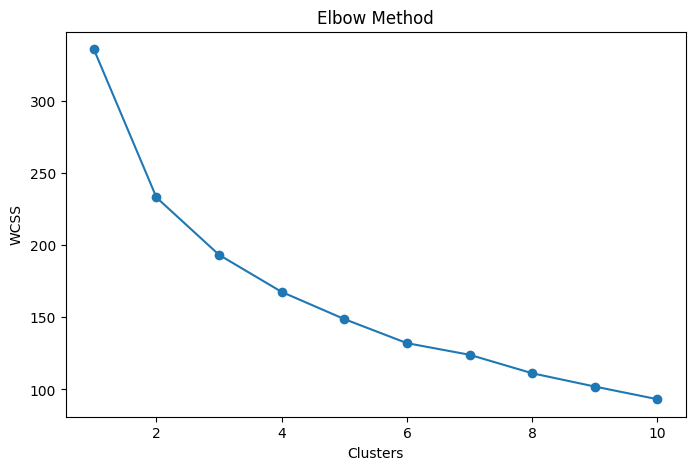

In [20]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

### Calculate the sillhout scores 

In [21]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    print(k, round(score,4))

2 0.3862
3 0.2159
4 0.1832
5 0.1646
6 0.1758
7 0.162
8 0.1583
9 0.1552
10 0.1486


## From our datasets the  best is 2 clusters 

In [37]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

df["cluster"] = kmeans.fit_predict(X_scaled)

### See the clusters summary 

In [23]:
cluster_summary = (
    df.groupby("cluster")[features]
      .mean()
      .round(2)
)

cluster_summary

,Current_Price,nav_discount_pct,distance_from_high,distance_from_low,intraday_volatility,premium_to_180d,log_volume,per_change
cluster,,,,,,,,
0,9.94,-4.34,9.11,14.65,2.78,2.99,9.10,0.39
1,11.92,-8.17,3.57,29.74,2.51,9.93,11.31,1.05


## Step 9: PCA Visualization

In [24]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df["PC1"] = components[:,0]
df["PC2"] = components[:,1]

### Show in the clusters 

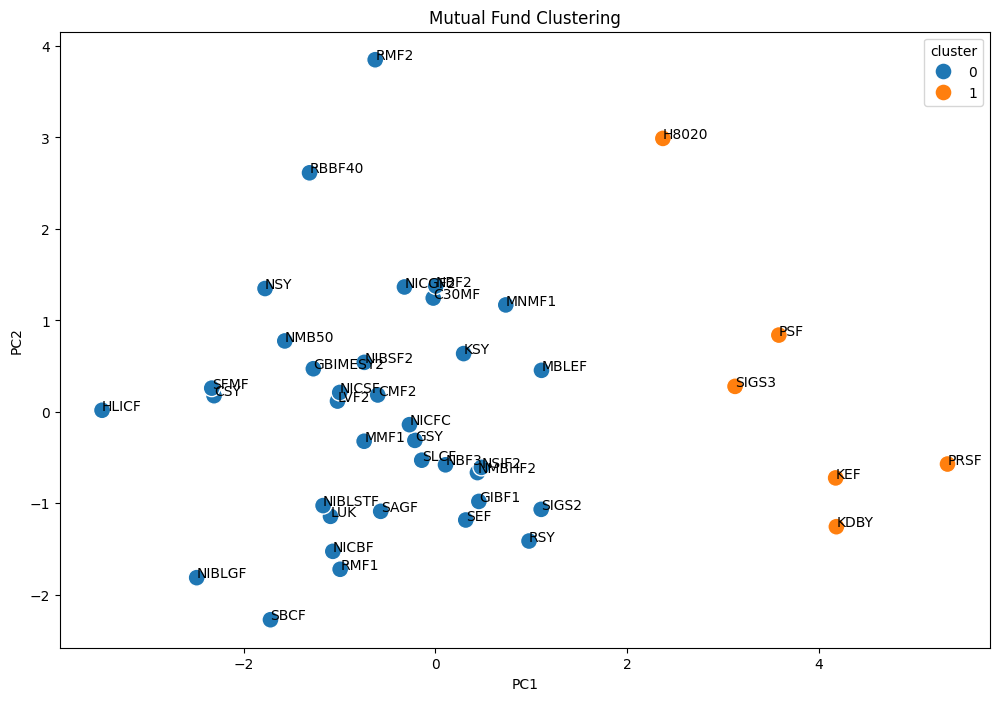

In [25]:
plt.figure(figsize=(12,8))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    s=150
)

for i,row in df.iterrows():
    plt.text(
        row["PC1"],
        row["PC2"],
        row["stockSymbol"]
    )

plt.title("Mutual Fund Clustering")

plt.show()

## 3d visualizations 

In [26]:
pca = PCA(n_components=3)

components = pca.fit_transform(X_scaled)

df["PC1"] = components[:,0]
df["PC2"] = components[:,1]
df["PC3"] = components[:,2]

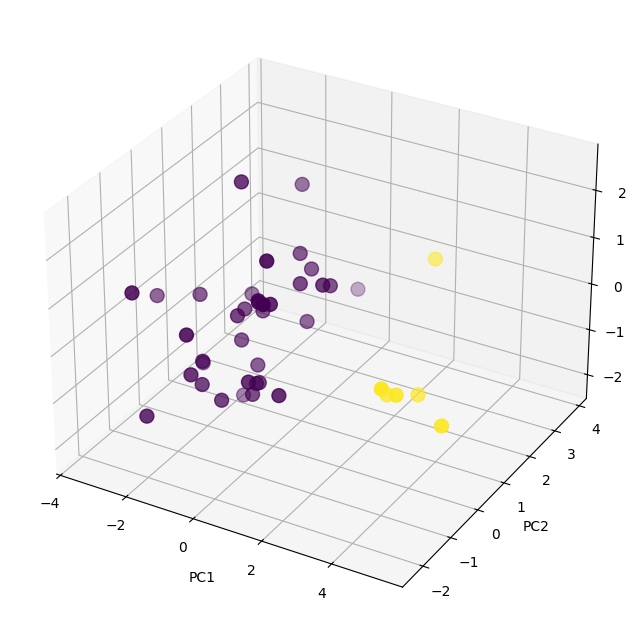

In [27]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12,8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    df["PC1"],
    df["PC2"],
    df["PC3"],
    c=df["cluster"],
    s=100
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

## Categorize the datas 

In [38]:
cluster_map = {
    0: "Value Funds",
    1: "Growth Funds"
}

df["Fund_Category"] = df["cluster"].map(cluster_map)

In [34]:
df.head()

,companyName,stockSymbol,Current_Price,Weekly NAV,Volume,180 Days Avg Price,time_stamps,price_change,per_change,Day_low,Day_High,52_weak_low,52_weak_high
0,Citizens Super 30 Mutual Fund,C30MF,10.19,10.76,1900,9.77,2026-05-27,0.19,1.90,9.92,10.19,8.70,10.71
1,Citizens Mutual Fund 2,CMF2,10.20,10.19,5009,9.88,2026-05-27,-0.04,-0.39,10.00,10.24,8.64,10.86
2,Citizens Santulit Yojana,CSY,9.35,9.81,1710,9.42,2026-05-27,0.04,0.43,9.31,9.50,8.87,10.00
3,Global IME Sammunat Yojana-2,GBIMESY2,9.35,10.23,13000,9.30,2026-05-27,0.00,0.00,9.21,9.80,8.50,10.18
4,Global IME Balanced Fund - 1,GIBF1,10.87,12.00,19450,10.72,2026-05-27,-0.13,-1.18,10.80,11.15,9.30,11.68


In [39]:
df['Fund_Category'].value_counts()

Fund_Category
Value Funds     36
Growth Funds     6
Name: count, dtype: int64

In [36]:
df

,companyName,stockSymbol,Current_Price,Weekly NAV,Volume,180 Days Avg Price,time_stamps,price_change,per_change,Day_low,Day_High,52_weak_low,52_weak_high
0,Citizens Super 30 Mutual Fund,C30MF,10.19,10.76,1900,9.77,2026-05-27,0.19,1.90,9.92,10.19,8.70,10.71
1,Citizens Mutual Fund 2,CMF2,10.20,10.19,5009,9.88,2026-05-27,-0.04,-0.39,10.00,10.24,8.64,10.86
2,Citizens Santulit Yojana,CSY,9.35,9.81,1710,9.42,2026-05-27,0.04,0.43,9.31,9.50,8.87,10.00
3,Global IME Sammunat Yojana-2,GBIMESY2,9.35,10.23,13000,9.30,2026-05-27,0.00,0.00,9.21,9.80,8.50,10.18
4,Global IME Balanced Fund - 1,GIBF1,10.87,12.00,19450,10.72,2026-05-27,-0.13,-1.18,10.80,11.15,9.30,11.68
5,Garima Samriddhi Yojana,GSY,9.99,10.47,2600,9.56,2026-05-27,0.00,0.00,9.95,9.99,8.70,10.40
6,Himalayan 80-20,H8020,12.25,12.64,37450,11.47,2026-05-27,0.25,2.08,11.75,12.56,10.00,12.33
7,HLI Large Cap Fund,HLICF,9.00,8.85,24670,9.26,2026-05-27,0.10,1.12,8.80,9.00,8.74,10.55
8,Kumari Dhanabriddhi Yojana,KDBY,11.51,12.90,477100,10.44,2026-05-27,0.04,0.35,11.46,11.67,8.67,12.54
9,Kumari Equity Fund,KEF,11.00,12.04,263899,9.82,2026-05-27,0.01,0.09,10.98,11.15,8.31,11.30


In [40]:
import os
os.getcwd()

'C:\\Users\\HP\\Desktop\\data_extractions\\iol case study'